# 02 — Case118: every table and figure from the frozen results

Reads `data/frozen/*.csv`, written by the stage code in `code/case118/`, and regenerates the case118
tables and figures of the paper (Tables 1, 3 and 4; Figures 5–7 and SM12) in seconds.
Numbers refer to the submitted version of the paper.
Rerunning the stages themselves takes hours; see `code/case118/README.md`.

In the data files the completed value $\mathcal J^+$ is called `Wplus`.

In [1]:
import sys, json
from pathlib import Path
import pandas as pd
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "scripts"))
import paper_figures as pf
DATA = ROOT / "data" / "frozen"
pd.set_option("display.width", 140, "display.precision", 6)

## Table 1 (case118 rows): certified gap under three pricings

In [2]:
c = pd.read_csv(DATA / "stage5a3_certificate_summary.csv")
m = c.J_refined.notna(); c.loc[m, "J"] = c.loc[m, "J_refined"]; c.loc[m, "J_se"] = c.loc[m, "J_refined_se"]
c["gap_%"] = 100 * (c.J - c.Jplus) / c.J
c["gap_se_%"] = 100 * c.J_se / c.J
c[["noise", "design", "J", "J_se", "Jplus", "gap_%", "gap_se_%"]].round(4)

,noise,design,J,J_se,Jplus,gap_%,gap_se_%
0,homogeneous,uniform,0.0772,0.0004,0.0750,2.7610,0.4541
1,homogeneous,robust_fixed,0.0773,0.0004,0.0736,4.7681,0.4543
2,homogeneous,activity_specific,0.0774,0.0004,0.0684,11.6197,0.4547
3,activity_scaled,uniform,0.0410,0.0003,0.0250,39.0558,0.8057
4,activity_scaled,robust_fixed,0.0409,0.0003,0.0388,5.2847,0.8022
5,activity_scaled,activity_specific,0.0410,0.0001,0.0406,1.1512,0.1863


## Table 3: deployed policies at $\sigma_{\rm rms}=0.15$

In [3]:
d = pd.read_csv(DATA / "stage3b_all_results.csv")
d[(d.sigma_rms == 0.15) & d.policy.isin(["static", "H2_droop", "H3_lqr"])][
    ["noise", "policy", "J_mean", "J_se", "cross_probability", "dmax_q99_deg", "n_paths"]]

,noise,policy,J_mean,J_se,cross_probability,dmax_q99_deg,n_paths
13,activity_scaled,H2_droop,0.041222,0.000323,0.182292,100.471585,192
16,activity_scaled,H3_lqr,0.040731,0.000315,0.166667,100.073195,192
17,activity_scaled,static,0.041297,0.000324,0.208333,101.452007,192
40,homogeneous,H2_droop,0.077062,0.000356,0.296875,102.029416,192
43,homogeneous,H3_lqr,0.076692,0.000352,0.291667,102.002467,192
44,homogeneous,static,0.077150,0.000357,0.328125,103.328193,192


## The hard completion (Table 4, activity-scaled H3) and its estimator bias
Lemma 5.1 gives the bias $\approx\frac\lambda2(1/\mathrm{ESS}-1/N)$ per replicate.

In [4]:
a = json.load(open(DATA / "STAGE4C_FINAL.json"))
lam, ess, N = a["lambda_max"], a["ess_absolute_mean"], a["n_paths_per_rep"]
print(f"J+ = {a['Wplus_mean']:.6f} ± {a['Wplus_rep_se']:.1e} (replicate s.e.), ESS fraction {a['ess_fraction_mean']:.3f}")
print(f"estimated Jensen bias = {lam/2*(1/ess-1/N):.1e}")

J+ = 0.024965 ± 1.7e-05 (replicate s.e.), ESS fraction 0.029
estimated Jensen bias = 5.8e-06


## Figures

In [5]:
out = ROOT / "figures" / "generated"
for f in [pf.fig_geometry, pf.fig_case118_certificate, pf.fig_case118_frontier,
          pf.fig_case118_sparse, pf.fig_case118_deployed]:
    print("wrote", f(out))

wrote /home/claude/sjco/repo/figures/generated/fig_geometry.pdf


wrote /home/claude/sjco/repo/figures/generated/fig_case118_certificate.pdf


wrote /home/claude/sjco/repo/figures/generated/fig_case118_frontier.pdf


wrote /home/claude/sjco/repo/figures/generated/fig_case118_sparse.pdf


wrote /home/claude/sjco/repo/figures/generated/fig_case118_deployed.pdf


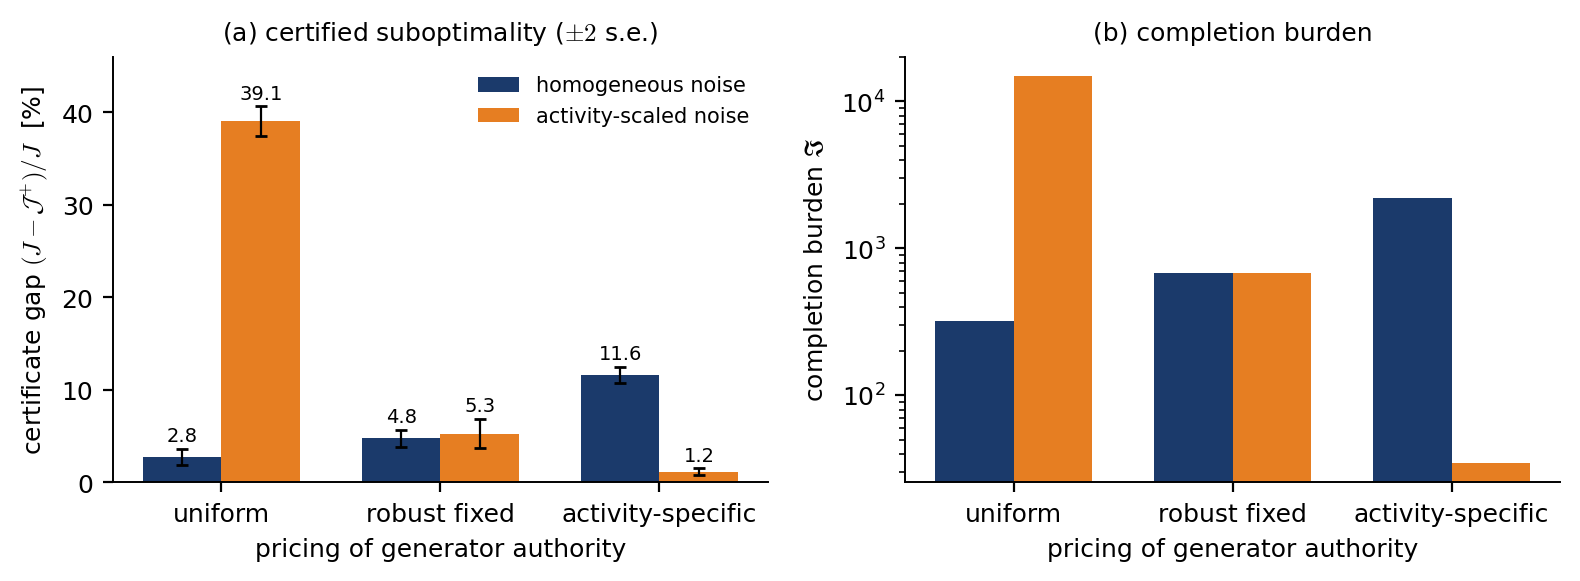

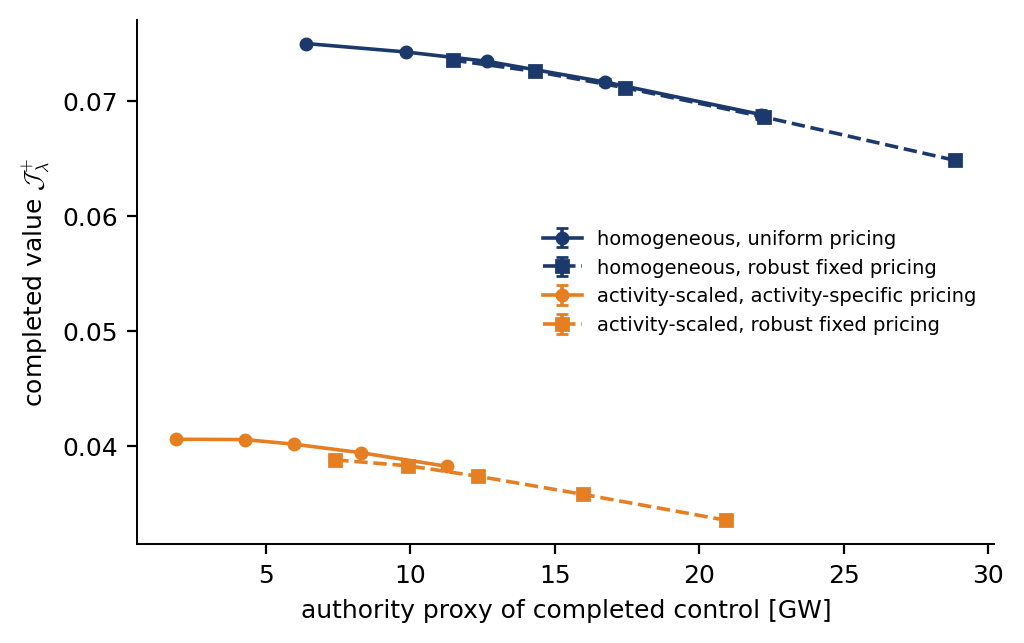

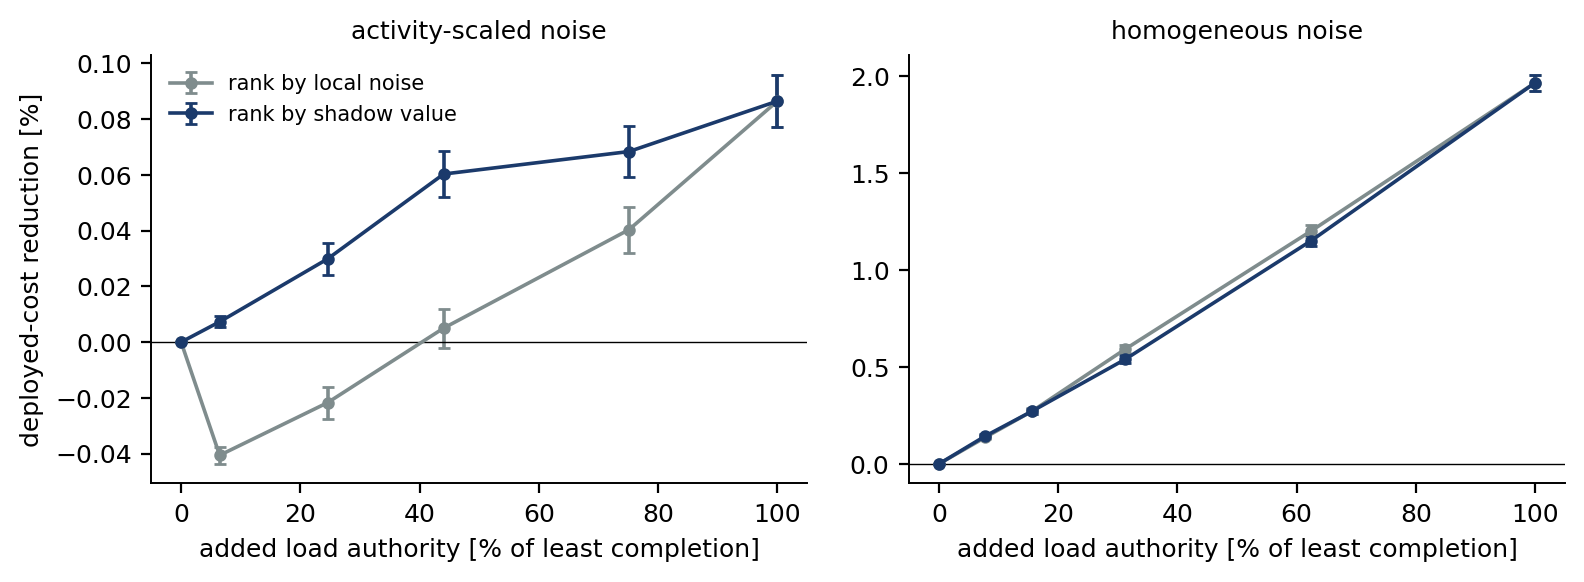

In [6]:
from IPython.display import Image, display
for name in ["fig_case118_certificate", "fig_case118_frontier", "fig_case118_sparse"]:
    display(Image(filename=str(out / f"{name}.png"), width=720))